# Mount drive

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


# Imports & Paths

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

# Project directories
PROJECT_DIR = Path(
    "/content/drive/MyDrive/Colab Notebooks/Dissertation"
)

RUNS_DIR = PROJECT_DIR / "Runs"
RESULTS_DIR = PROJECT_DIR / "Results"

OUTPUT_DIR = RESULTS_DIR / "weather_wise_analysis"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if not RUNS_DIR.exists():
    raise FileNotFoundError(
        f"Runs directory not found: {RUNS_DIR}"
    )

print("Runs directory:", RUNS_DIR)
print("Output directory:", OUTPUT_DIR)

Runs directory: /content/drive/MyDrive/Colab Notebooks/Dissertation/Runs
Output directory: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/weather_wise_analysis


# Load summary files

In [ ]:
def load_all_result_summaries(runs_directory):
    """
    Load all compatible experiment summary CSV files.

    The function also converts the old YOLO DAWN
    weather_results_summary.csv format automatically.
    """

    summary_files = sorted(
        file_path
        for file_path in runs_directory.rglob("*.csv")
        if "summary" in file_path.name.lower()
    )

    loaded_frames = []
    ignored_files = []

    required_columns = {
        "model",
        "experiment",
        "seed",
        "condition",
        "mAP50-95",
        "mAP50",
    }

    for file_path in summary_files:

        try:
            current_df = pd.read_csv(file_path)

            # Old YOLO DAWN format
            is_old_yolo_dawn_format = (
                file_path.name == "weather_results_summary.csv"
                and list(current_df.columns)
                == ["global", "fog", "rain", "snow"]
                and len(current_df) == 4
            )

            if is_old_yolo_dawn_format:

                current_df.index = [
                    "mAP50",
                    "mAP50-95",
                    "Precision",
                    "Recall",
                ]

                current_df = (
                    current_df
                    .T
                    .reset_index()
                    .rename(columns={"index": "condition"})
                )

                current_df.insert(0, "seed", 42)
                current_df.insert(0, "experiment", "in_domain")
                current_df.insert(0, "model", "YOLOv11s")
                current_df.insert(0, "dataset", "DAWN")

                precision = current_df["Precision"]
                recall = current_df["Recall"]

                current_df["F1-score"] = np.where(
                    precision + recall > 0,
                    2 * precision * recall / (precision + recall),
                    np.nan,
                )

            # Normal result files
            elif not required_columns.issubset(current_df.columns):

                missing_columns = sorted(
                    required_columns - set(current_df.columns)
                )

                ignored_files.append(
                    {
                        "file": str(
                            file_path.relative_to(runs_directory)
                        ),
                        "reason": (
                            f"Missing columns: {missing_columns}"
                        ),
                    }
                )

                continue

            current_df["source_file"] = str(
                file_path.relative_to(runs_directory)
            )

            loaded_frames.append(current_df)

        except Exception as error:

            ignored_files.append(
                {
                    "file": str(
                        file_path.relative_to(runs_directory)
                    ),
                    "reason": str(error),
                }
            )

    if not loaded_frames:
        raise RuntimeError(
            "No compatible result summary file was found."
        )

    results_df = pd.concat(
        loaded_frames,
        ignore_index=True,
        sort=False,
    )

    ignored_df = pd.DataFrame(ignored_files)

    print("Summary files found:", len(summary_files))
    print("Loaded files:", len(loaded_frames))
    print("Loaded rows:", len(results_df))
    print("Ignored files:", len(ignored_files))

    return results_df, ignored_df

### Load results

In [ ]:
raw_results_df, ignored_files_df = (
    load_all_result_summaries(RUNS_DIR)
)

display(raw_results_df.head())

Summary files found: 13
Loaded files: 13
Loaded rows: 52
Ignored files: 0


,dataset,model,experiment,seed,condition,mAP50-95,mAP50,mAP75,Inference_ms_per_image,FPS,source_file,source_train_dataset,target_test_dataset,Precision,Recall,F1-score
0,ACDC,Faster R-CNN,in_domain,123,global,0.4283,0.6121,0.4556,61.7702,16.1890,faster_rcnn/acdc_in_domain_faster_rcnn_seed123...,NaN,NaN,NaN,NaN,NaN
1,ACDC,Faster R-CNN,in_domain,123,fog,0.5722,0.7643,0.6215,61.7869,16.1847,faster_rcnn/acdc_in_domain_faster_rcnn_seed123...,NaN,NaN,NaN,NaN,NaN
2,ACDC,Faster R-CNN,in_domain,123,rain,0.3745,0.5446,0.3881,60.9978,16.3940,faster_rcnn/acdc_in_domain_faster_rcnn_seed123...,NaN,NaN,NaN,NaN,NaN
3,ACDC,Faster R-CNN,in_domain,123,snow,0.5154,0.6973,0.5677,61.9047,16.1539,faster_rcnn/acdc_in_domain_faster_rcnn_seed123...,NaN,NaN,NaN,NaN,NaN
4,ACDC,Faster R-CNN,in_domain,42,global,0.4128,0.5963,0.4499,62.1002,16.1030,faster_rcnn/acdc_in_domain_faster_rcnn_seed42/...,NaN,NaN,NaN,NaN,NaN


### Check ignored files

In [ ]:
if ignored_files_df.empty:
    print("No result summary file was ignored.")
else:
    display(ignored_files_df)

No result summary file was ignored.


# Standardize results

In [ ]:
def standardise_results(dataframe):
    """
    Standardise column names, text values and numeric types.
    """

    dataframe = dataframe.copy()

    dataframe.columns = [
        column.strip()
        for column in dataframe.columns
    ]

    text_columns = [
        "dataset",
        "source_train_dataset",
        "target_test_dataset",
        "model",
        "experiment",
        "condition",
    ]

    for column in text_columns:
        if column in dataframe.columns:
            dataframe[column] = (
                dataframe[column]
                .astype("string")
                .str.strip()
            )

    model_mapping = {
        "YOLO": "YOLOv11s",
        "YOLO11s": "YOLOv11s",
        "YOLOv11s": "YOLOv11s",
        "FasterRCNN": "Faster R-CNN",
        "Faster RCNN": "Faster R-CNN",
        "Faster R-CNN": "Faster R-CNN",
    }

    dataframe["model"] = dataframe["model"].replace(
        model_mapping
    )

    dataframe["experiment"] = (
        dataframe["experiment"]
        .str.lower()
        .str.replace("-", "_", regex=False)
        .str.replace(" ", "_", regex=False)
    )

    dataframe["condition"] = (
        dataframe["condition"]
        .str.lower()
    )

    if "dataset" not in dataframe.columns:
        dataframe["dataset"] = pd.NA

    if "source_train_dataset" in dataframe.columns:
        dataframe["dataset"] = dataframe["dataset"].fillna(
            dataframe["source_train_dataset"]
        )

    dataframe["dataset"] = (
        dataframe["dataset"]
        .str.upper()
    )

    numeric_columns = [
        "seed",
        "mAP50-95",
        "mAP50",
        "mAP75",
        "Precision",
        "Recall",
        "F1-score",
        "Inference_ms_per_image",
        "FPS",
    ]

    for column in numeric_columns:
        if column in dataframe.columns:
            dataframe[column] = pd.to_numeric(
                dataframe[column],
                errors="coerce",
            )

    return dataframe

### Apply Cleaning

In [ ]:
results_df = standardise_results(raw_results_df)

print("Models:")
print(results_df["model"].value_counts(dropna=False))

print("\nExperiments:")
print(results_df["experiment"].value_counts(dropna=False))

print("\nSeeds:")
print(sorted(results_df["seed"].dropna().unique()))

print("\nConditions:")
print(results_df["condition"].value_counts(dropna=False))

Models:
model
Faster R-CNN    44
YOLOv11s         8
Name: count, dtype: Int64

Experiments:
experiment
in_domain     28
acdc_>dawn    12
dawn_>acdc    12
Name: count, dtype: Int64

Seeds:
[np.int64(42), np.int64(123), np.int64(456)]

Conditions:
condition
global    13
fog       13
rain      13
snow      13
Name: count, dtype: Int64


# Select meteo in-domain results

In [ ]:
weather_conditions = [
    "fog",
    "rain",
    "snow",
]

weather_df = results_df[
    results_df["experiment"].str.contains(
        r"in[_-]?domain",
        case=False,
        na=False,
        regex=True,
    )
    & (results_df["seed"] == 42)
    & (results_df["condition"].isin(weather_conditions))
].copy()

weather_df = (
    weather_df
    .sort_values(
        ["dataset", "model", "condition"]
    )
    .reset_index(drop=True)
)

print("Weather-specific rows:", len(weather_df))

display(
    weather_df[
        [
            column
            for column in [
                "dataset",
                "model",
                "seed",
                "condition",
                "mAP50-95",
                "mAP50",
                "mAP75",
                "Precision",
                "Recall",
                "F1-score",
            ]
            if column in weather_df.columns
        ]
    ]
)

Weather-specific rows: 12


,dataset,model,seed,condition,mAP50-95,mAP50,mAP75,Precision,Recall,F1-score
0,ACDC,Faster R-CNN,42,fog,0.5472,0.7540,0.5907,NaN,NaN,NaN
1,ACDC,Faster R-CNN,42,rain,0.3631,0.5262,0.3973,NaN,NaN,NaN
2,ACDC,Faster R-CNN,42,snow,0.4889,0.6951,0.5272,NaN,NaN,NaN
3,ACDC,YOLOv11s,42,fog,0.4127,0.6277,0.4272,0.8584,0.5470,0.6682
4,ACDC,YOLOv11s,42,rain,0.3081,0.4836,0.3194,0.7661,0.4058,0.5306
5,ACDC,YOLOv11s,42,snow,0.3560,0.5598,0.3648,0.7243,0.4606,0.5631
6,DAWN,Faster R-CNN,42,fog,0.4153,0.5998,0.4766,NaN,NaN,NaN
7,DAWN,Faster R-CNN,42,rain,0.5160,0.7635,0.5799,NaN,NaN,NaN
8,DAWN,Faster R-CNN,42,snow,0.4724,0.7651,0.6000,NaN,NaN,NaN
9,DAWN,YOLOv11s,42,fog,0.3847,0.6153,NaN,0.8055,0.5621,0.6621


# Coverage check

In [ ]:
coverage_table = (
    weather_df
    .groupby(["dataset", "model"])
    .agg(
        number_of_conditions=("condition", "nunique"),
        conditions=(
            "condition",
            lambda values: ", ".join(
                sorted(values.dropna().unique())
            ),
        ),
    )
    .reset_index()
)

display(coverage_table)

,dataset,model,number_of_conditions,conditions
0,ACDC,Faster R-CNN,3,"fog, rain, snow"
1,ACDC,YOLOv11s,3,"fog, rain, snow"
2,DAWN,Faster R-CNN,3,"fog, rain, snow"
3,DAWN,YOLOv11s,3,"fog, rain, snow"


# Duplication checks

In [ ]:
duplicate_key = [
    "dataset",
    "model",
    "seed",
    "condition",
]

duplicate_rows = weather_df[
    weather_df.duplicated(
        subset=duplicate_key,
        keep=False,
    )
]

if duplicate_rows.empty:
    print("No duplicated weather result was found.")
else:
    print("Warning: duplicated weather results were found.")

    display(
        duplicate_rows[
            duplicate_key
            + [
                "mAP50-95",
                "source_file",
            ]
        ]
    )

No duplicated weather result was found.


# mAP@0.50:0.95 table

In [ ]:
weather_map_table = weather_df.pivot_table(
    index=["dataset", "model"],
    columns="condition",
    values="mAP50-95",
    aggfunc="first",
)

weather_map_table = weather_map_table.reindex(
    columns=["fog", "rain", "snow"]
)

weather_map_table = (
    weather_map_table
    .reset_index()
    .rename(
        columns={
            "dataset": "Dataset",
            "model": "Model",
            "fog": "Fog",
            "rain": "Rain",
            "snow": "Snow",
        }
    )
)

display(weather_map_table.round(4))

condition,Dataset,Model,Fog,Rain,Snow
0,ACDC,Faster R-CNN,0.5472,0.3631,0.4889
1,ACDC,YOLOv11s,0.4127,0.3081,0.3560
2,DAWN,Faster R-CNN,0.4153,0.5160,0.4724
3,DAWN,YOLOv11s,0.3847,0.3573,0.4520


### save

In [ ]:
weather_map_table_path = (
    TABLES_DIR
    / "weather_map50_95_publication.csv"
)

weather_map_table.to_csv(
    weather_map_table_path,
    index=False,
)

weather_df.to_csv(
    TABLES_DIR / "weather_results_complete.csv",
    index=False,
)

print("Saved:", weather_map_table_path)

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/weather_wise_analysis/tables/weather_map50_95_publication.csv


# Function for meteo graph

In [ ]:
def plot_weather_metric(
    dataframe,
    dataset_name,
    metric,
    ylabel,
    title,
    output_filename,
    decimals=3,
):
    """
    Create a grouped bar chart comparing weather conditions
    for both models on one dataset.
    """

    if metric not in dataframe.columns:
        print(f"{metric} is not available.")
        return

    dataset_df = dataframe[
        dataframe["dataset"] == dataset_name
    ].dropna(
        subset=["model", "condition", metric]
    )

    if dataset_df.empty:
        print(
            f"No valid {metric} values for {dataset_name}."
        )
        return

    plot_df = dataset_df.pivot_table(
        index="condition",
        columns="model",
        values=metric,
        aggfunc="first",
    )

    plot_df = plot_df.reindex(
        ["fog", "rain", "snow"]
    )

    preferred_models = [
        "YOLOv11s",
        "Faster R-CNN",
    ]

    available_models = [
        model
        for model in preferred_models
        if model in plot_df.columns
    ]

    plot_df = plot_df.reindex(
        columns=available_models
    )

    axis = plot_df.plot(
        kind="bar",
        figsize=(8, 5),
        width=0.75,
    )

    axis.set_title(title)
    axis.set_xlabel("Weather condition")
    axis.set_ylabel(ylabel)
    axis.tick_params(axis="x", rotation=0)

    axis.set_xticklabels(
        ["Fog", "Rain", "Snow"]
    )

    axis.legend(
        title="Model",
        frameon=False,
    )

    axis.grid(
        axis="y",
        linestyle="--",
        alpha=0.4,
    )

    for container_item in axis.containers:
        axis.bar_label(
            container_item,
            fmt=f"%.{decimals}f",
            padding=3,
            fontsize=9,
        )

    plt.tight_layout()

    output_path = FIGURES_DIR / output_filename

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print("Saved:", output_path)

## mAP@0.50:0.95 on ACDC

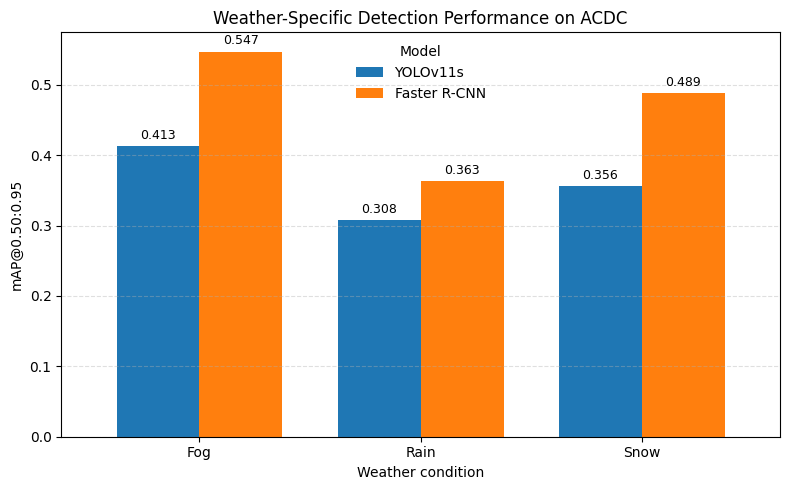

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/weather_wise_analysis/figures/acdc_weather_map50_95.png


In [ ]:
plot_weather_metric(
    dataframe=weather_df,
    dataset_name="ACDC",
    metric="mAP50-95",
    ylabel="mAP@0.50:0.95",
    title="Weather-Specific Detection Performance on ACDC",
    output_filename="acdc_weather_map50_95.png",
)

## mAP@0.50:0.95 on DAWN

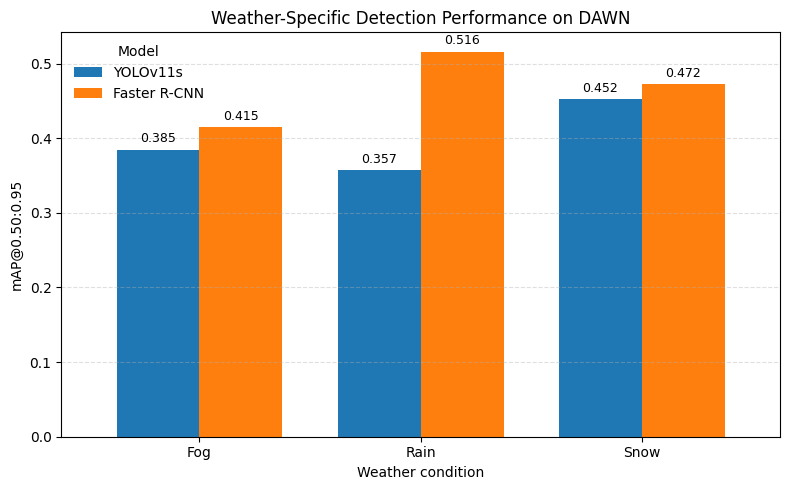

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/weather_wise_analysis/figures/dawn_weather_map50_95.png


In [ ]:
plot_weather_metric(
    dataframe=weather_df,
    dataset_name="DAWN",
    metric="mAP50-95",
    ylabel="mAP@0.50:0.95",
    title="Weather-Specific Detection Performance on DAWN",
    output_filename="dawn_weather_map50_95.png",
)

## mAP@0.50 on ACDC

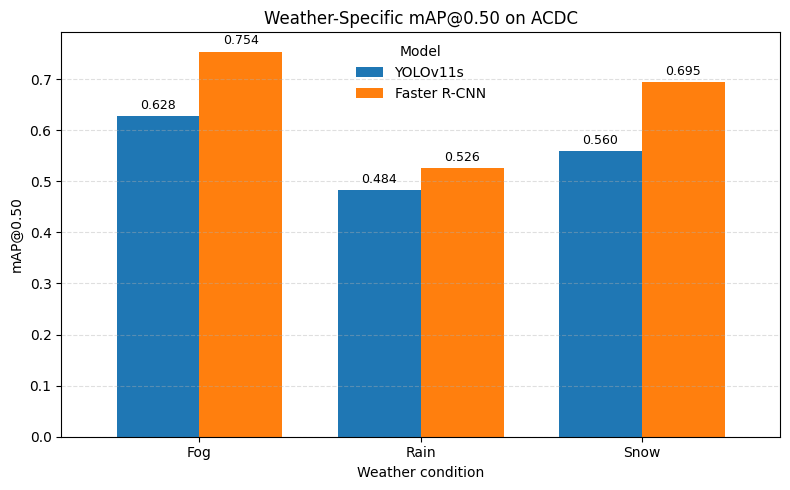

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/weather_wise_analysis/figures/acdc_weather_map50.png


In [ ]:
plot_weather_metric(
    dataframe=weather_df,
    dataset_name="ACDC",
    metric="mAP50",
    ylabel="mAP@0.50",
    title="Weather-Specific mAP@0.50 on ACDC",
    output_filename="acdc_weather_map50.png",
)

## mAP@0.50 on DAWN

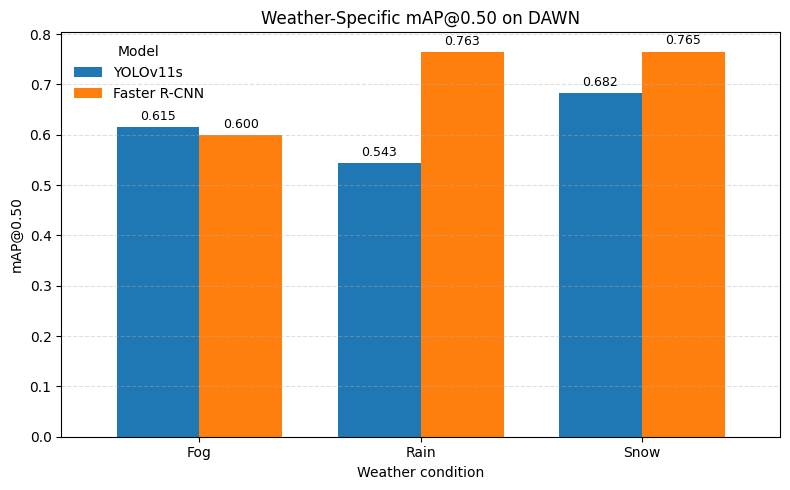

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/weather_wise_analysis/figures/dawn_weather_map50.png


In [ ]:
plot_weather_metric(
    dataframe=weather_df,
    dataset_name="DAWN",
    metric="mAP50",
    ylabel="mAP@0.50",
    title="Weather-Specific mAP@0.50 on DAWN",
    output_filename="dawn_weather_map50.png",
)

## mAP@0.75 on ACDC

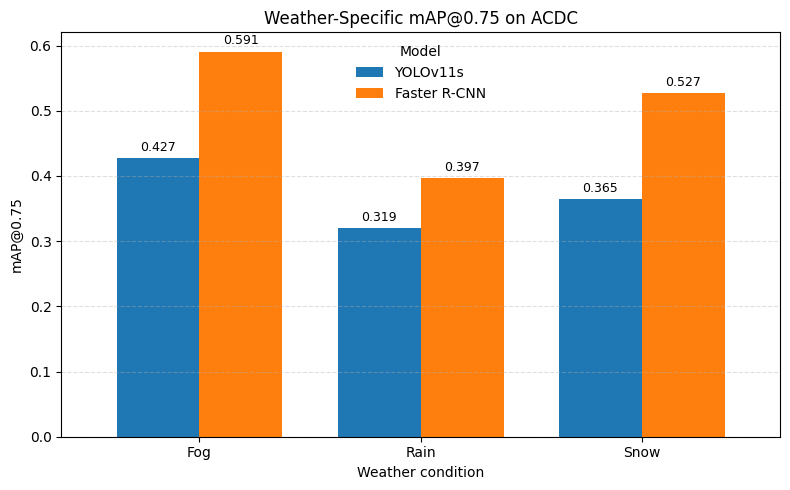

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/weather_wise_analysis/figures/acdc_weather_map75.png


In [ ]:
plot_weather_metric(
    dataframe=weather_df,
    dataset_name="ACDC",
    metric="mAP75",
    ylabel="mAP@0.75",
    title="Weather-Specific mAP@0.75 on ACDC",
    output_filename="acdc_weather_map75.png",
)

## mAP@0.75 on DAWN

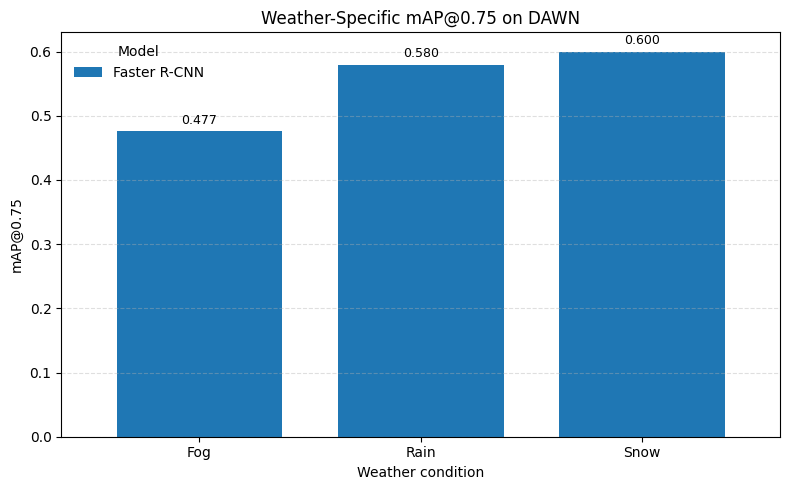

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/weather_wise_analysis/figures/dawn_weather_map75.png


In [ ]:
plot_weather_metric(
    dataframe=weather_df,
    dataset_name="DAWN",
    metric="mAP75",
    ylabel="mAP@0.75",
    title="Weather-Specific mAP@0.75 on DAWN",
    output_filename="dawn_weather_map75.png",
)

# Function for heatmaps

In [ ]:
def plot_weather_heatmap(
    dataframe,
    dataset_name,
    metric,
    title,
    output_filename,
):
    """
    Create a heatmap using matplotlib.
    """

    dataset_df = dataframe[
        dataframe["dataset"] == dataset_name
    ]

    heatmap_df = dataset_df.pivot_table(
        index="model",
        columns="condition",
        values=metric,
        aggfunc="first",
    )

    model_order = [
        model
        for model in [
            "YOLOv11s",
            "Faster R-CNN",
        ]
        if model in heatmap_df.index
    ]

    heatmap_df = heatmap_df.reindex(
        index=model_order,
        columns=["fog", "rain", "snow"],
    )

    values = heatmap_df.to_numpy(
        dtype=float
    )

    fig, axis = plt.subplots(
        figsize=(7, 3.5)
    )

    image = axis.imshow(
        values,
        aspect="auto",
    )

    axis.set_xticks(
        range(len(heatmap_df.columns))
    )

    axis.set_xticklabels(
        ["Fog", "Rain", "Snow"]
    )

    axis.set_yticks(
        range(len(heatmap_df.index))
    )

    axis.set_yticklabels(
        heatmap_df.index
    )

    axis.set_title(title)

    for row_index in range(values.shape[0]):
        for column_index in range(values.shape[1]):

            value = values[
                row_index,
                column_index,
            ]

            label = (
                f"{value:.3f}"
                if not np.isnan(value)
                else "N/A"
            )

            axis.text(
                column_index,
                row_index,
                label,
                ha="center",
                va="center",
            )

    colorbar = plt.colorbar(
        image,
        ax=axis,
    )

    colorbar.set_label(metric)

    plt.tight_layout()

    output_path = FIGURES_DIR / output_filename

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print("Saved:", output_path)

## Heatmap on ACDC

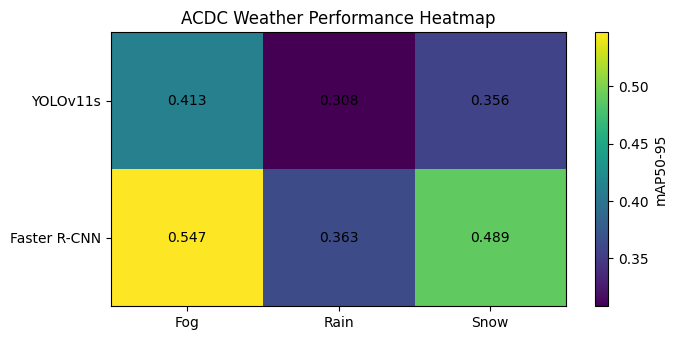

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/weather_wise_analysis/figures/acdc_weather_heatmap.png


In [ ]:
plot_weather_heatmap(
    dataframe=weather_df,
    dataset_name="ACDC",
    metric="mAP50-95",
    title="ACDC Weather Performance Heatmap",
    output_filename="acdc_weather_heatmap.png",
)

## Heatmap on DAWN

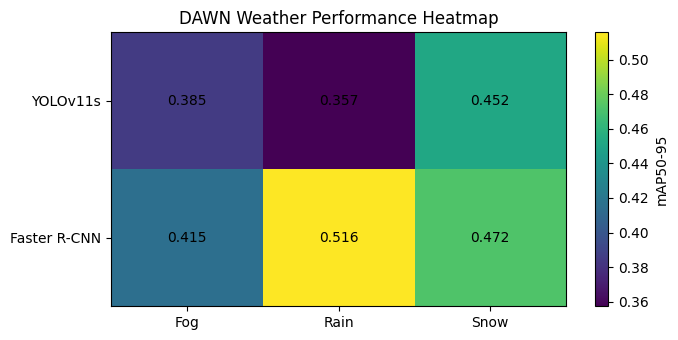

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/weather_wise_analysis/figures/dawn_weather_heatmap.png


In [ ]:
plot_weather_heatmap(
    dataframe=weather_df,
    dataset_name="DAWN",
    metric="mAP50-95",
    title="DAWN Weather Performance Heatmap",
    output_filename="dawn_weather_heatmap.png",
)

# Classify meteo conditions

In [ ]:
weather_ranking_rows = []

for (dataset, model), group_df in weather_df.groupby(
    ["dataset", "model"]
):

    valid_group = group_df.dropna(
        subset=["mAP50-95"]
    )

    if valid_group.empty:
        continue

    best_row = valid_group.loc[
        valid_group["mAP50-95"].idxmax()
    ]

    worst_row = valid_group.loc[
        valid_group["mAP50-95"].idxmin()
    ]

    weather_ranking_rows.append(
        {
            "Dataset": dataset,
            "Model": model,
            "Best condition": best_row["condition"].title(),
            "Best mAP@0.50:0.95": best_row["mAP50-95"],
            "Worst condition": worst_row["condition"].title(),
            "Worst mAP@0.50:0.95": worst_row["mAP50-95"],
            "Performance range": (
                best_row["mAP50-95"]
                - worst_row["mAP50-95"]
            ),
        }
    )

weather_ranking_table = pd.DataFrame(
    weather_ranking_rows
)

display(weather_ranking_table.round(4))

,Dataset,Model,Best condition,Best mAP@0.50:0.95,Worst condition,Worst mAP@0.50:0.95,Performance range
0,ACDC,Faster R-CNN,Fog,0.5472,Rain,0.3631,0.1842
1,ACDC,YOLOv11s,Fog,0.4127,Rain,0.3081,0.1045
2,DAWN,Faster R-CNN,Rain,0.5160,Fog,0.4153,0.1007
3,DAWN,YOLOv11s,Snow,0.4520,Rain,0.3573,0.0947


## Calculate weather differences

In [ ]:
weather_delta_rows = []

for (dataset, model), group_df in weather_df.groupby(
    ["dataset", "model"]
):

    metric_values = (
        group_df
        .set_index("condition")["mAP50-95"]
        .to_dict()
    )

    if not all(
        condition in metric_values
        for condition in ["fog", "rain", "snow"]
    ):
        continue

    weather_delta_rows.append(
        {
            "Dataset": dataset,
            "Model": model,
            "Fog - Rain": (
                metric_values["fog"]
                - metric_values["rain"]
            ),
            "Snow - Rain": (
                metric_values["snow"]
                - metric_values["rain"]
            ),
            "Snow - Fog": (
                metric_values["snow"]
                - metric_values["fog"]
            ),
        }
    )

weather_delta_table = pd.DataFrame(
    weather_delta_rows
)

display(weather_delta_table.round(4))

,Dataset,Model,Fog - Rain,Snow - Rain,Snow - Fog
0,ACDC,Faster R-CNN,0.1842,0.1258,-0.0584
1,ACDC,YOLOv11s,0.1045,0.0478,-0.0567
2,DAWN,Faster R-CNN,-0.1007,-0.0436,0.0571
3,DAWN,YOLOv11s,0.0274,0.0947,0.0673


# Compare models directly

In [ ]:
model_comparison_rows = []

for dataset in sorted(
    weather_df["dataset"].dropna().unique()
):

    for condition in weather_conditions:

        comparison_df = weather_df[
            (weather_df["dataset"] == dataset)
            & (weather_df["condition"] == condition)
        ].set_index("model")

        if not {
            "YOLOv11s",
            "Faster R-CNN",
        }.issubset(comparison_df.index):
            continue

        yolo_value = comparison_df.loc[
            "YOLOv11s",
            "mAP50-95",
        ]

        faster_value = comparison_df.loc[
            "Faster R-CNN",
            "mAP50-95",
        ]

        model_comparison_rows.append(
            {
                "Dataset": dataset,
                "Condition": condition.title(),
                "YOLOv11s": yolo_value,
                "Faster R-CNN": faster_value,
                "Absolute difference": (
                    faster_value - yolo_value
                ),
                "Better model": (
                    "Faster R-CNN"
                    if faster_value > yolo_value
                    else "YOLOv11s"
                ),
            }
        )

weather_model_comparison = pd.DataFrame(
    model_comparison_rows
)

display(weather_model_comparison.round(4))

,Dataset,Condition,YOLOv11s,Faster R-CNN,Absolute difference,Better model
0,ACDC,Fog,0.4127,0.5472,0.1346,Faster R-CNN
1,ACDC,Rain,0.3081,0.3631,0.0549,Faster R-CNN
2,ACDC,Snow,0.3560,0.4889,0.1329,Faster R-CNN
3,DAWN,Fog,0.3847,0.4153,0.0306,Faster R-CNN
4,DAWN,Rain,0.3573,0.5160,0.1587,Faster R-CNN
5,DAWN,Snow,0.4520,0.4724,0.0204,Faster R-CNN


# Save tables

In [ ]:
weather_ranking_table.to_csv(
    TABLES_DIR / "weather_condition_ranking.csv",
    index=False,
)

weather_delta_table.to_csv(
    TABLES_DIR / "weather_condition_differences.csv",
    index=False,
)

weather_model_comparison.to_csv(
    TABLES_DIR / "weather_model_comparison.csv",
    index=False,
)

print("Weather analysis tables saved.")

Weather analysis tables saved.


# Interpretation

In [ ]:
interpretation_lines = []

for _, row in weather_ranking_table.iterrows():

    interpretation_lines.append(
        (
            f'On {row["Dataset"]}, {row["Model"]} achieved '
            f'its highest weather-specific performance under '
            f'{row["Best condition"].lower()} conditions '
            f'(mAP@0.50:0.95 = '
            f'{row["Best mAP@0.50:0.95"]:.3f}). '
            f'Its lowest performance was observed under '
            f'{row["Worst condition"].lower()} conditions '
            f'(mAP@0.50:0.95 = '
            f'{row["Worst mAP@0.50:0.95"]:.3f}).'
        )
    )

interpretation_text = "\n\n".join(
    interpretation_lines
)

print(interpretation_text)

On ACDC, Faster R-CNN achieved its highest weather-specific performance under fog conditions (mAP@0.50:0.95 = 0.547). Its lowest performance was observed under rain conditions (mAP@0.50:0.95 = 0.363).

On ACDC, YOLOv11s achieved its highest weather-specific performance under fog conditions (mAP@0.50:0.95 = 0.413). Its lowest performance was observed under rain conditions (mAP@0.50:0.95 = 0.308).

On DAWN, Faster R-CNN achieved its highest weather-specific performance under rain conditions (mAP@0.50:0.95 = 0.516). Its lowest performance was observed under fog conditions (mAP@0.50:0.95 = 0.415).

On DAWN, YOLOv11s achieved its highest weather-specific performance under snow conditions (mAP@0.50:0.95 = 0.452). Its lowest performance was observed under rain conditions (mAP@0.50:0.95 = 0.357).


In [ ]:
overall_weather_summary = (
    weather_df
    .groupby("condition")["mAP50-95"]
    .mean()
    .sort_values(ascending=False)
)

best_overall_condition = (
    overall_weather_summary.index[0]
)

worst_overall_condition = (
    overall_weather_summary.index[-1]
)

summary_text = (
    "Across all in-domain model and dataset combinations, "
    f"{best_overall_condition} produced the highest average "
    f"mAP@0.50:0.95 "
    f"({overall_weather_summary.iloc[0]:.3f}), while "
    f"{worst_overall_condition} produced the lowest average "
    f"performance "
    f"({overall_weather_summary.iloc[-1]:.3f}). "
    "However, the weather ranking was not identical across "
    "all datasets and models, indicating that weather effects "
    "also depend on the training dataset and model architecture."
)

print(summary_text)

display(
    overall_weather_summary
    .rename("Mean mAP@0.50:0.95")
    .reset_index()
)

Across all in-domain model and dataset combinations, snow produced the highest average mAP@0.50:0.95 (0.442), while rain produced the lowest average performance (0.386). However, the weather ranking was not identical across all datasets and models, indicating that weather effects also depend on the training dataset and model architecture.


,condition,Mean mAP@0.50:0.95
0,snow,0.4423
1,fog,0.4400
2,rain,0.3861


### Save interpretation

In [ ]:
full_interpretation = (
    interpretation_text
    + "\n\nOverall summary:\n"
    + summary_text
)

interpretation_path = (
    OUTPUT_DIR
    / "weather_wise_interpretation.txt"
)

interpretation_path.write_text(
    full_interpretation,
    encoding="utf-8",
)

print("Saved:", interpretation_path)

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/weather_wise_analysis/weather_wise_interpretation.txt


# Generated files

In [ ]:
generated_files = sorted(
    file_path
    for file_path in OUTPUT_DIR.rglob("*")
    if file_path.is_file()
)

print(f"Generated files: {len(generated_files)}\n")

for file_path in generated_files:
    print(file_path.relative_to(OUTPUT_DIR))

Generated files: 14

figures/acdc_weather_heatmap.png
figures/acdc_weather_map50.png
figures/acdc_weather_map50_95.png
figures/acdc_weather_map75.png
figures/dawn_weather_heatmap.png
figures/dawn_weather_map50.png
figures/dawn_weather_map50_95.png
figures/dawn_weather_map75.png
tables/weather_condition_differences.csv
tables/weather_condition_ranking.csv
tables/weather_map50_95_publication.csv
tables/weather_model_comparison.csv
tables/weather_results_complete.csv
weather_wise_interpretation.txt
